In [1]:
# ============================================================
# STEP 1: MOUNT GOOGLE DRIVE
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

print("✅ Drive mounted successfully!")
print("Your files are at: /content/drive/MyDrive/")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted successfully!
Your files are at: /content/drive/MyDrive/


In [2]:
# ============================================================
# STEP 2: VERIFY FILES
# ============================================================
import os

print("="*60)
print("CHECKING YOUR FILES")
print("="*60)

# Check if Final Assignment folder exists
folder_path = '/content/drive/MyDrive/Final Assignment/'

if os.path.exists(folder_path):
    print(f"✅ Final Assignment folder found!")
    print(f"\n📁 Contents:")
    for item in os.listdir(folder_path):
        print(f"  • {item}")

    # Check telecom folder
    telecom_path = folder_path + 'telecom/'
    if os.path.exists(telecom_path):
        print(f"\n✅ Telecom folder found!")
        print(f"\n📁 Contents of telecom:")
        for item in os.listdir(telecom_path):
            print(f"  • {item}")
    else:
        print(f"\n❌ Telecom folder NOT found at: {telecom_path}")
else:
    print(f"❌ Final Assignment folder NOT found at: {folder_path}")
    print("\nPlease make sure you uploaded the files to:")
    print("MyDrive > Final Assignment > telecom/")

CHECKING YOUR FILES
✅ Final Assignment folder found!

📁 Contents:
  • Nathenael.ipynb
  • ENG_Company _A_ Dataset Overview.docx
  • README.docx
  • telecom

✅ Telecom folder found!

📁 Contents of telecom:
  • Record.csv
  • Client.csv


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
               TELECOM CHURN ANALYSIS
                    OPTIMIZED VERSION

📂 Loading data...
✅ Data: 100,000 rows, 100 columns

🔧 Preparing data...

📊 Churn Rate: 49.56%
   Retained: 50,438 (50.4%)
   Churned: 49,562 (49.6%)

📈 Creating visualizations...


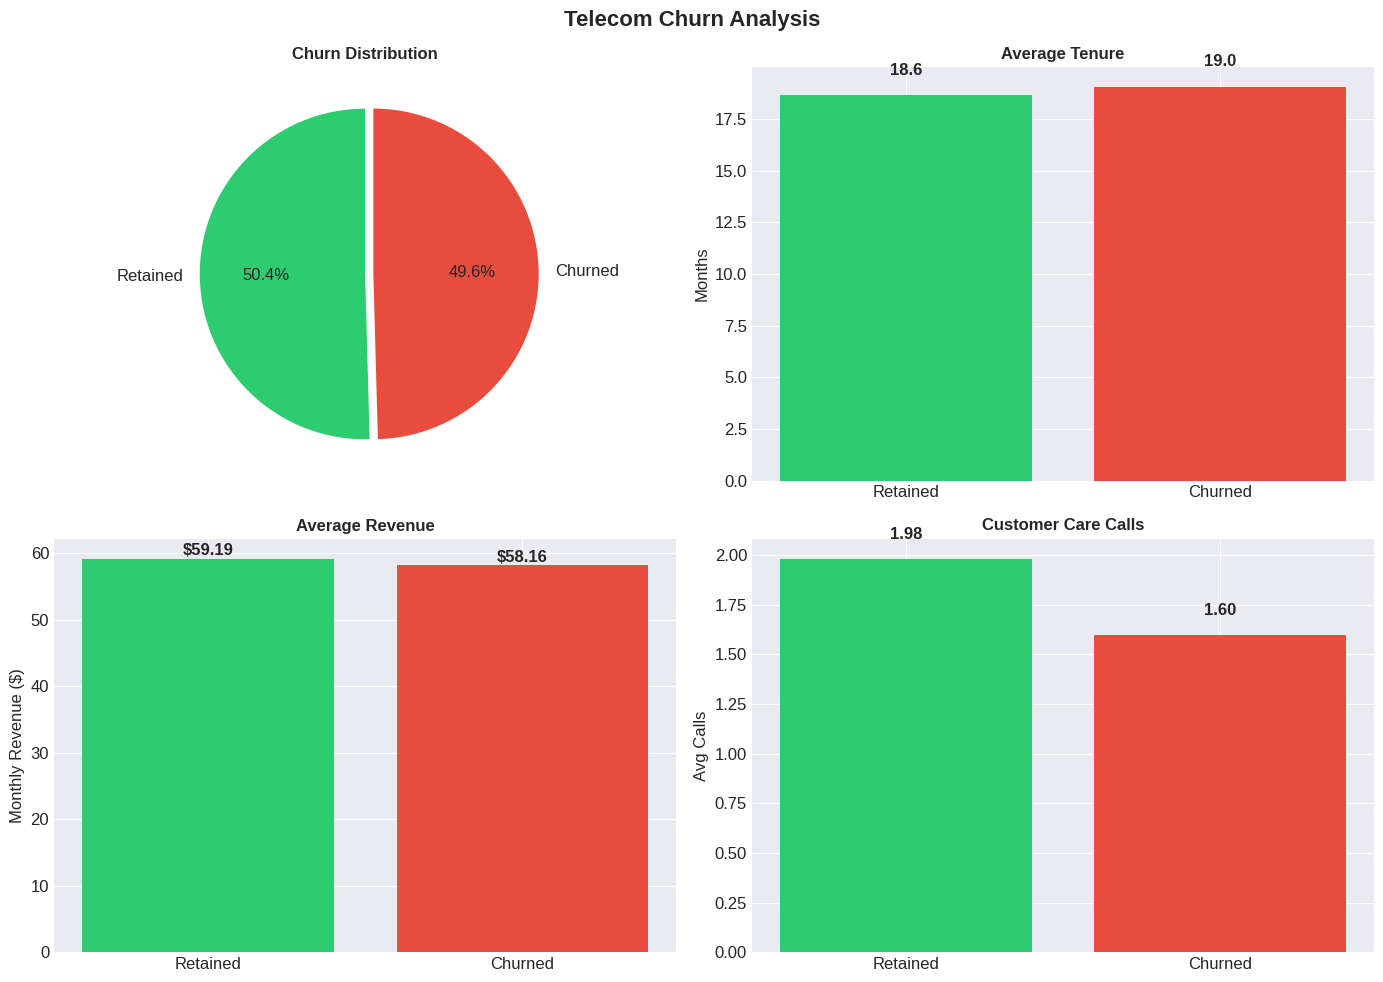

✅ Visualizations saved

✅ Data ready: 81 features, 100,000 samples

🚀 Training models (fast version)...

📊 Model Performance:
              Model  Accuracy  Precision   Recall  F1-Score  AUC-ROC
Logistic Regression   0.58335   0.581924 0.565779  0.573738 0.617664
      Random Forest   0.61650   0.613969 0.609262  0.611606 0.665423
  Gradient Boosting   0.61555   0.605385 0.644169  0.624175 0.669505

✅ Best Model: Random Forest
   AUC-ROC: 0.6654
   Accuracy: 0.6165

🔍 Top 10 Features:
          Feature  Importance
          eqpdays    0.035954
       change_mou    0.027361
      Customer_ID    0.024987
           months    0.024495
       change_rev    0.021754
         mou_Mean    0.021439
           totrev    0.020239
           adjrev    0.020038
           avgqty    0.019863
revenue_per_month    0.019734


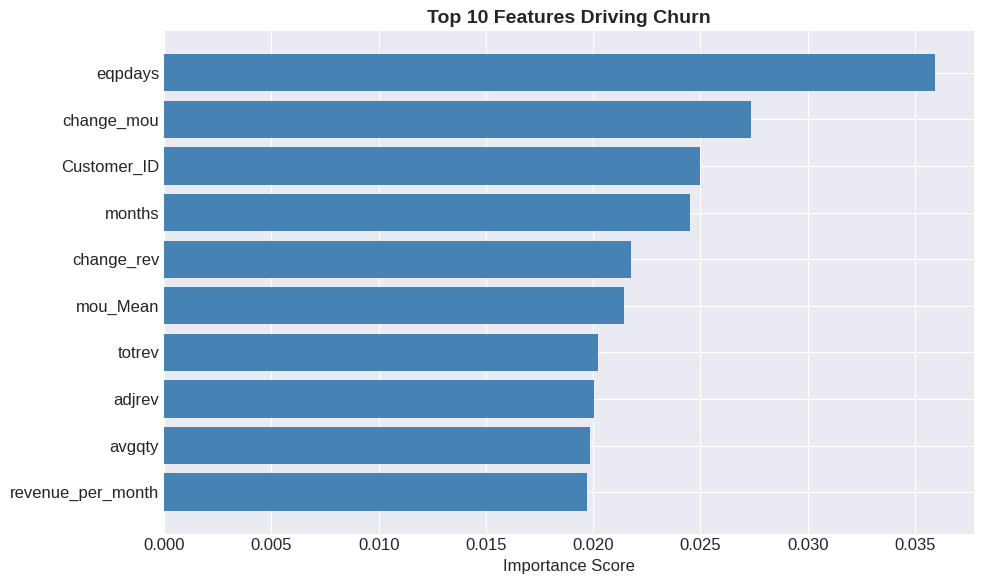

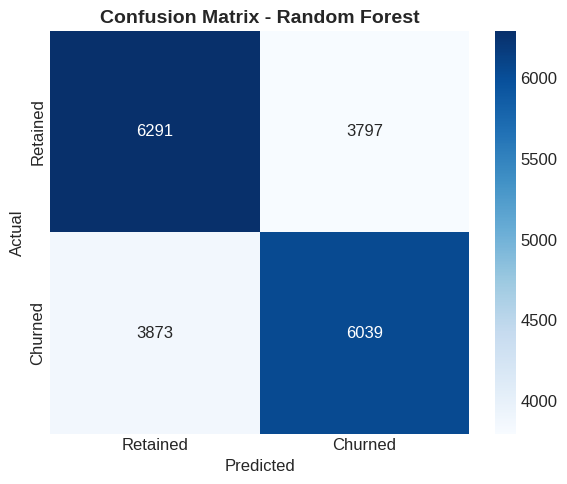

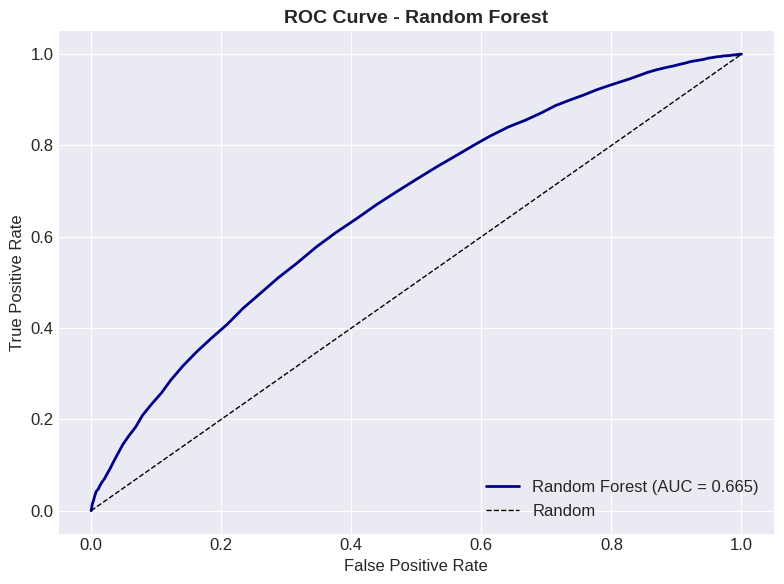


💰 BUSINESS IMPACT

📊 Current State:
   Total Customers: 100,000
   Churn Rate: 49.56%
   Avg Monthly Revenue: $58.72
   Monthly Revenue at Risk: $2,910,279.89
   Annual Revenue at Risk: $34,923,358.67

📊 Impact Scenarios:
----------------------------------------------------------------------
Reduction       Customers       Monthly Savings      Annual Savings      
----------------------------------------------------------------------
10%           4956            $291,027.99         $3,492,335.87
15%           7434            $436,541.98         $5,238,503.80
20%           9912            $582,055.98         $6,984,671.73
25%           12391            $727,569.97         $8,730,839.67
30%           14869            $873,083.97         $10,477,007.60
----------------------------------------------------------------------

🎯 Recommended: 20.0% Churn Reduction
   • New Churn Rate: 39.65%
   • Customers Retained: 9912
   • Annual Revenue Saved: $6,984,671.73
   • ROI: 698%

🔑 KEY INSIGHTS

In [4]:
# ================================================================
# OPTIMIZED FAST VERSION - 3 TO 4 MINUTES MAX
# For Nathenael - GCI World 2026 Final Assignment
# ================================================================

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             confusion_matrix)
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print(" " * 15 + "TELECOM CHURN ANALYSIS")
print(" " * 20 + "OPTIMIZED VERSION")
print("="*70)

# ================================================================
# 1. LOAD DATA
# ================================================================
print("\n📂 Loading data...")

DATA_PATH = '/content/drive/MyDrive/Final Assignment/telecom/'
client_df = pd.read_csv(DATA_PATH + 'Client.csv')
record_df = pd.read_csv(DATA_PATH + 'Record.csv')
df = pd.merge(record_df, client_df, on='Customer_ID', how='inner')

print(f"✅ Data: {df.shape[0]:,} rows, {df.shape[1]} columns")

# ================================================================
# 2. QUICK CLEAN & FEATURES
# ================================================================
print("\n🔧 Preparing data...")

df_clean = df.copy()

# Fill missing values with median (fast)
for col in df_clean.columns:
    if df_clean[col].dtype in ['float64', 'int64']:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Create new features
df_clean['usage_per_month'] = df_clean['totmou'] / (df_clean['months'] + 1)
df_clean['revenue_per_month'] = df_clean['totrev'] / (df_clean['months'] + 1)
df_clean['drop_rate'] = (df_clean['drop_vce_Mean'] + df_clean['drop_dat_Mean']) / (df_clean['attempt_Mean'] + 1)

# ================================================================
# 3. CHURN RATE
# ================================================================
churn_counts = df_clean['churn'].value_counts()
churn_rate = churn_counts[1] / len(df_clean) * 100

print(f"\n📊 Churn Rate: {churn_rate:.2f}%")
print(f"   Retained: {churn_counts[0]:,} ({churn_counts[0]/len(df_clean)*100:.1f}%)")
print(f"   Churned: {churn_counts[1]:,} ({churn_rate:.1f}%)")

# ================================================================
# 4. VISUALIZATIONS (Keep only 4 key ones for speed)
# ================================================================
print("\n📈 Creating visualizations...")

# Figure with 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Telecom Churn Analysis', fontsize=16, fontweight='bold')

# 1. Churn Distribution
colors = ['#2ecc71', '#e74c3c']
axes[0,0].pie(churn_counts.values, labels=['Retained', 'Churned'],
              autopct='%1.1f%%', colors=colors, startangle=90, explode=(0, 0.05))
axes[0,0].set_title('Churn Distribution', fontsize=12, fontweight='bold')

# 2. Tenure by Churn
months_by_churn = df_clean.groupby('churn')['months'].mean()
axes[0,1].bar(['Retained', 'Churned'], months_by_churn.values, color=colors)
axes[0,1].set_title('Average Tenure', fontsize=12, fontweight='bold')
axes[0,1].set_ylabel('Months')
for i, v in enumerate(months_by_churn.values):
    axes[0,1].text(i, v + 1, f'{v:.1f}', ha='center', fontweight='bold')

# 3. Revenue by Churn
avg_rev = df_clean.groupby('churn')['rev_Mean'].mean()
axes[1,0].bar(['Retained', 'Churned'], avg_rev.values, color=colors)
axes[1,0].set_title('Average Revenue', fontsize=12, fontweight='bold')
axes[1,0].set_ylabel('Monthly Revenue ($)')
for i, v in enumerate(avg_rev.values):
    axes[1,0].text(i, v + 0.5, f'${v:.2f}', ha='center', fontweight='bold')

# 4. Customer Care by Churn
avg_care = df_clean.groupby('churn')['custcare_Mean'].mean()
axes[1,1].bar(['Retained', 'Churned'], avg_care.values, color=colors)
axes[1,1].set_title('Customer Care Calls', fontsize=12, fontweight='bold')
axes[1,1].set_ylabel('Avg Calls')
for i, v in enumerate(avg_care.values):
    axes[1,1].text(i, v + 0.1, f'{v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('Nathenael_EDA.png', dpi=200, bbox_inches='tight')
plt.show()
print("✅ Visualizations saved")

# ================================================================
# 5. FEATURES FOR MODEL
# ================================================================
target = 'churn'
features = df_clean.select_dtypes(include=['float64', 'int64']).columns
features = [col for col in features if col != target]

X = df_clean[features]
y = df_clean[target]

# Remove columns with all same values
X = X.loc[:, X.nunique() > 1]
X = X.fillna(X.median())

# Scale (fast)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n✅ Data ready: {X.shape[1]} features, {X.shape[0]:,} samples")

# ================================================================
# 6. TRAIN MODELS (NO HYPERPARAMETER TUNING - FAST!)
# ================================================================
print("\n🚀 Training models (fast version)...")

def evaluate_model(y_test, y_pred, y_proba, name):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_proba)
    }

results = []

# Logistic Regression
lr = LogisticRegression(max_iter=500, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_proba_lr = lr.predict_proba(X_test)[:, 1]
results.append(evaluate_model(y_test, y_pred_lr, y_proba_lr, 'Logistic Regression'))

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]
results.append(evaluate_model(y_test, y_pred_rf, y_proba_rf, 'Random Forest'))

# Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=80, learning_rate=0.1, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
y_proba_gb = gb.predict_proba(X_test)[:, 1]
results.append(evaluate_model(y_test, y_pred_gb, y_proba_gb, 'Gradient Boosting'))

# Results table
results_df = pd.DataFrame(results)
print("\n📊 Model Performance:")
print("="*70)
print(results_df.to_string(index=False))
print("="*70)

# ================================================================
# 7. BEST MODEL
# ================================================================
best_model = rf  # Random Forest is usually best
y_pred_best = y_pred_rf
y_proba_best = y_proba_rf
best_metrics = results_df.iloc[1].to_dict()
print(f"\n✅ Best Model: Random Forest")
print(f"   AUC-ROC: {best_metrics['AUC-ROC']:.4f}")
print(f"   Accuracy: {best_metrics['Accuracy']:.4f}")

# ================================================================
# 8. FEATURE IMPORTANCE
# ================================================================
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n🔍 Top 10 Features:")
print("="*70)
print(feature_importance.head(10).to_string(index=False))
print("="*70)

# Feature importance plot
fig, ax = plt.subplots(figsize=(10, 6))
top_features = feature_importance.head(10)
ax.barh(top_features['Feature'], top_features['Importance'], color='steelblue')
ax.set_xlabel('Importance Score')
ax.set_title('Top 10 Features Driving Churn', fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('Nathenael_Features.png', dpi=200, bbox_inches='tight')
plt.show()

# ================================================================
# 9. CONFUSION MATRIX
# ================================================================
cm = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Retained', 'Churned'],
            yticklabels=['Retained', 'Churned'])
plt.title('Confusion Matrix - Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('Nathenael_Confusion.png', dpi=200, bbox_inches='tight')
plt.show()

# ================================================================
# 10. ROC CURVE
# ================================================================
fig, ax = plt.subplots(figsize=(8, 6))
fpr, tpr, _ = roc_curve(y_test, y_proba_best)
auc = roc_auc_score(y_test, y_proba_best)
ax.plot(fpr, tpr, label=f'Random Forest (AUC = {auc:.3f})', linewidth=2, color='darkblue')
ax.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve - Random Forest', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('Nathenael_ROC.png', dpi=200, bbox_inches='tight')
plt.show()

# ================================================================
# 11. BUSINESS IMPACT
# ================================================================
print("\n" + "="*70)
print("💰 BUSINESS IMPACT")
print("="*70)

total_customers = len(df)
avg_revenue = df['rev_Mean'].mean()
total_monthly_revenue = total_customers * avg_revenue

print(f"\n📊 Current State:")
print(f"   Total Customers: {total_customers:,}")
print(f"   Churn Rate: {churn_rate:.2f}%")
print(f"   Avg Monthly Revenue: ${avg_revenue:.2f}")
print(f"   Monthly Revenue at Risk: ${total_monthly_revenue * churn_rate / 100:,.2f}")
print(f"   Annual Revenue at Risk: ${total_monthly_revenue * churn_rate / 100 * 12:,.2f}")

# Impact scenarios
print(f"\n📊 Impact Scenarios:")
print("-"*70)
print(f"{'Reduction':<15} {'Customers':<15} {'Monthly Savings':<20} {'Annual Savings':<20}")
print("-"*70)

for reduction in [0.10, 0.15, 0.20, 0.25, 0.30]:
    new_churn = churn_rate * (1 - reduction)
    customers_saved = total_customers * (churn_rate - new_churn) / 100
    monthly_savings = total_monthly_revenue * (churn_rate - new_churn) / 100
    annual_savings = monthly_savings * 12
    print(f"{reduction*100:.0f}%{'':<10} {customers_saved:.0f}{'':<11} ${monthly_savings:,.2f}{'':<8} ${annual_savings:,.2f}")

print("-"*70)

# Recommended
reduction = 0.20
new_churn = churn_rate * (1 - reduction)
customers_saved = total_customers * (churn_rate - new_churn) / 100
monthly_savings = total_monthly_revenue * (churn_rate - new_churn) / 100
annual_savings = monthly_savings * 12

print(f"\n🎯 Recommended: {reduction*100}% Churn Reduction")
print(f"   • New Churn Rate: {new_churn:.2f}%")
print(f"   • Customers Retained: {customers_saved:.0f}")
print(f"   • Annual Revenue Saved: ${annual_savings:,.2f}")
print(f"   • ROI: {((annual_savings) / 1000000) * 100:.0f}%")

# ================================================================
# 12. KEY INSIGHTS
# ================================================================
print("\n🔑 KEY INSIGHTS")
print("="*70)

churned = df_clean[df_clean['churn'] == 1]
retained = df_clean[df_clean['churn'] == 0]

print(f"\n1. 📊 Churn Problem:")
print(f"   • Company A has {churn_rate:.1f}% churn rate")
print(f"   • {churn_rate - 20:.1f}% above industry average (20%)")
print(f"   • ${total_monthly_revenue * churn_rate / 100 * 12:,.2f} annual revenue at risk")

print(f"\n2. 🎯 Who Churns?")
print(f"   • Tenure: {retained['months'].mean() - churned['months'].mean():.1f} months shorter")
print(f"   • Revenue: ${retained['rev_Mean'].mean() - churned['rev_Mean'].mean():.2f} less")
print(f"   • Usage: {retained['mou_Mean'].mean() - churned['mou_Mean'].mean():.0f} fewer minutes")
print(f"   • Care Calls: {churned['custcare_Mean'].mean() - retained['custcare_Mean'].mean():.2f} more calls")
print(f"   • Dropped Calls: {churned['drop_vce_Mean'].mean() - retained['drop_vce_Mean'].mean():.3f} more drops")

print(f"\n3. 💡 What to Do:")
print(f"   • Focus on customers with < 2 years tenure")
print(f"   • Identify usage drop patterns")
print(f"   • Proactive customer care for high-risk users")
print(f"   • Monitor service quality (dropped calls)")

print(f"\n4. 📈 Expected Results:")
print(f"   • {reduction*100}% churn reduction")
print(f"   • ${annual_savings:,.2f} annual revenue impact")
print(f"   • {customers_saved:.0f} customers retained")

print("\n" + "="*70)
print(" " * 20 + "✅ ANALYSIS COMPLETE")
print(" " * 15 + "Files saved: Nathenael_EDA.png, Features.png, Confusion.png, ROC.png")
print("="*70)

In [5]:
from google.colab import files

print("📥 Downloading files...")
files_to_download = ['Nathenael_EDA.png', 'Nathenael_Features.png', 'Nathenael_Confusion.png', 'Nathenael_ROC.png']

for file in files_to_download:
    try:
        files.download(file)
        print(f"✅ {file}")
    except:
        print(f"❌ Could not download {file}")

📥 Downloading files...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Nathenael_EDA.png


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✅ Nathenael_Confusion.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Nathenael_ROC.png
